In [3]:
import napari
import numpy as np
from skimage.io import imread
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mutual_info_score
import os
import tqdm
import scipy.ndimage as ndimage
from deepcell.utils.plot_utils import create_rgb_image
from skimage.io import imsave, imread
import re
import glob
#import squidpy as sq
%matplotlib inline
fig_out_folder = './figures/'
isExist = os.path.exists(fig_out_folder)
if not isExist:

   # Create a new directory because it does not exist
   os.makedirs(fig_out_folder)

In [4]:
tiff_name = 'Leap042_6'
segmentation_path = '../../segmentation/'
borders = imread(segmentation_path+'deepcell_visualization/'+tiff_name+'_segmentation_borders.tiff')
img = imread(segmentation_path+'deepcell_input_Denoised/'+tiff_name+'.tiff')
img = create_rgb_image(np.expand_dims(img,axis = 0), channel_colors=['green', 'blue'])[0]

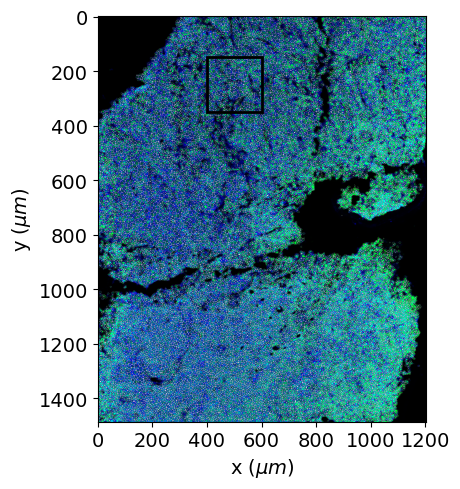

In [20]:
from matplotlib.patches import Rectangle
alpha = borders.copy()
plt.figure(figsize=(5, 5))
alpha[alpha > 0] = 1
alpha = np.array(alpha,dtype = float)
plt.imshow(img,alpha = 1-alpha)
plt.imshow(borders,cmap = 'gray',alpha = alpha)

zoom_x_s,zoom_x_e = 400,600
zoom_y_s,zoom_y_e = 150,350

rectangle = Rectangle((zoom_x_s,zoom_y_s),width=zoom_x_e-zoom_x_s,height=zoom_y_e-zoom_y_s,lw = 2,fill = False)
plt.gca().add_patch(rectangle)
plt.xlabel('x ($\mu m$)',fontsize = 14)
plt.ylabel('y ($\mu m$)',fontsize = 14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
#plt.savefig('../figures/segmentation/'+tiff_name+'.png',transparent = True)

/tmp/ipykernel_293382/4035999877.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels)
/tmp/ipykernel_293382/4035999877.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)


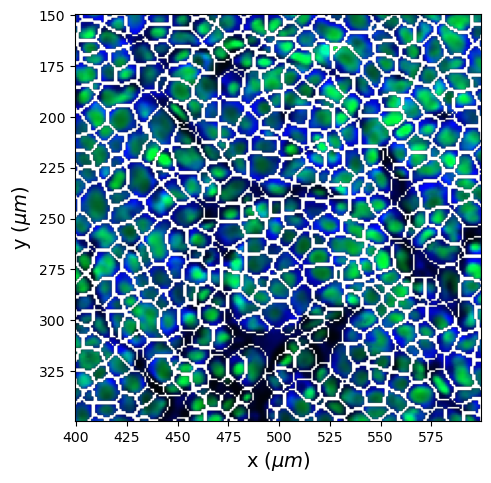

In [19]:
plt.figure(figsize=(5, 5))
plt.imshow(img[zoom_y_s:zoom_y_e,zoom_x_s:zoom_x_e],alpha =  1-alpha[zoom_y_s:zoom_y_e,zoom_x_s:zoom_x_e])
plt.imshow(borders[zoom_y_s:zoom_y_e,zoom_x_s:zoom_x_e],alpha =  alpha[zoom_y_s:zoom_y_e,zoom_x_s:zoom_x_e],cmap = 'gray')
ax = plt.gca()
labels = [re.sub(r'[^\x00-\x7F]+','-', item.get_text()) for item in ax.get_xticklabels()]#the - sign is non asci, I need regex to convert
labels = np.array(labels,dtype = int)+zoom_x_s
ax.set_xticklabels(labels)
labels = [re.sub(r'[^\x00-\x7F]+','-', item.get_text()) for item in ax.get_yticklabels()]#the - sign is non asci, I need regex to convert
labels = np.array(labels,dtype = int)+zoom_y_s
ax.set_yticklabels(labels)
plt.xlabel('x ($\mu m$)',fontsize = 14)
plt.ylabel('y ($\mu m$)',fontsize = 16)
plt.tight_layout()
#plt.savefig('../figures/segmentation/'+tiff_name+'_zoom.png',transparent = True)